# 0.1 Physical-AI-SCA 통합 데모 — TraceWhisperer 제외

이 노트북은 실제 IUT 기계어 에뮬레이션과 CW308T-STM32F3 실물 전력을 한 흐름에서 수집·분석·보고·검증한다. 에뮬레이션은 명령어별 HW·HD 모델과 `sample_map`으로 구현 후보를 찾고, 실물 전력은 글리치·커플링을 포함한 물리 관측을 제공한다. 어느 채널도 다른 채널을 대신하지 않으며, 깨끗한 결과 하나로 안전이나 적합성을 주장하지 않는다.

결과 등급은 `TA·SPA·DPA` 필수 시험, 에뮬레이션 `soundness` 판정, 참고용 CPA 양성 대조로 분리한다. 표본 부족과 사람의 SPA 육안 검사 미수행은 `inconclusive`이며 pass가 아니다. `cw_debugtrace`와 인위적 고장·복구 시나리오는 제외한다.

In [1]:
from pathlib import Path
import json, os, shutil, subprocess, sys
import h5py, matplotlib.pyplot as plt, numpy as np, pandas as pd

PROJECT = Path.cwd()
if PROJECT.name == 'demo': PROJECT = PROJECT.parent
assert (PROJECT / 'physai').is_dir(), PROJECT
os.chdir(PROJECT)
sys.path.insert(0, str(PROJECT))
from physai import demo, spec, verify
import chipwhisperer as cw

spec_paths = [PROJECT / 'exp' / f'{name}.yaml' for name in demo.RUNS]
specs = [spec.load(path) for path in spec_paths]
devices = cw.list_devices()
inventory = {}
for kind in ('ChipWhisperer_Lite', 'ChipWhisperer_Husky'):
    matches = [d for d in devices if d['name'].replace('-', '_') == kind]
    assert len(matches) == 1, f'{kind}: {len(matches)}대'
    inventory[kind] = {'name': matches[0]['name'], 'serial_suffix': str(matches[0]['sn'])[-4:]}
assert all(sum(s['n'] for s in sp['subsets']) == (2568 if 'emul' in sp['id'] else 332) for sp in specs)
assert all(sp['seed'] == 1234 for sp in specs)
print('명세 4개, seed=1234, 장비 종류별 1대 확인')
print(json.dumps(inventory, ensure_ascii=False, indent=2))
print('Grok 감사 파일:', (PROJECT / 'runs/grok_audit.json').is_file())

/usr/local/lib/python3.12/site-packages/chipwhisperer/capture/trace/TraceWhisperer.py:31: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources # type: ignore


명세 4개, seed=1234, 장비 종류별 1대 확인
{
  "ChipWhisperer_Lite": {
    "name": "ChipWhisperer-Lite",
    "serial_suffix": "3035"
  },
  "ChipWhisperer_Husky": {
    "name": "ChipWhisperer-Husky",
    "serial_suffix": "3032"
  }
}
Grok 감사 파일: True


## 에뮬레이션 selftest와 ELF 빌드

selftest는 두 IUT의 골든 AES, masked 마스크 회수, 입력에 무관한 명령어 수, 누설 벡터 길이를 실제 실행으로 확인한다. 명령어 수가 변하면 `sample_map`이 무효이므로 즉시 중단한다.

In [2]:
def run(cmd):
    result = subprocess.run(cmd, cwd=PROJECT, text=True, capture_output=True)
    log = (result.stdout + '\n' + result.stderr).strip()
    print('\n'.join(log.splitlines()[-18:]))
    if result.returncode: raise RuntimeError(f'rc={result.returncode}: {cmd}')
    return result

run([sys.executable, '-m', 'physai.collectors.emulation', '--selftest', '--n', '10'])
for iut in ('tiny-AES-c', 'masked-aes-c'):
    run(['make', '-C', 'emul_harness', f'IUT={iut}'])

  ① 골든 AES 일치   : 예 (10/10)
  ② 마스크          : 10바이트, 고유 10/10
  ③ 명령어 수       : 10147–10147 → 고정
  ④ 1장당 시간      : 53.8 ms (19 tr/s)
  ⑤ 샘플/트레이스   : 40588
     leakage_model  : concat(HW(reg), HD(reg,same), HW(mem), HD(mem,same))
     build_flags    : -mcpu=cortex-m4 -mthumb -mfloat-abi=soft -Os -funsigned-char -funsigned-bitfields -fshort-enums -std=gnu99 -ffunction-sections -fmessage-length=0 -gdwarf-2 -I../../iut/masked-aes-c -I. -DCBC=0 -DCTR=0 -DMASKED=1
 tiny-AES-c   sha256 6e02db26e09b…
  ① 골든 AES 일치   : 예 (10/10)
  ② 마스크          : 해당없음
  ③ 명령어 수       : 6030–6030 → 고정
  ④ 1장당 시간      : 30.2 ms (33 tr/s)
  ⑤ 샘플/트레이스   : 24120
     leakage_model  : concat(HW(reg), HD(reg,same), HW(mem), HD(mem,same))
     build_flags    : -mcpu=cortex-m4 -mthumb -mfloat-abi=soft -Os -funsigned-char -funsigned-bitfields -fshort-enums -std=gnu99 -ffunction-sections -fmessage-length=0 -gdwarf-2 -I../../iut/tiny-AES-c -I. -DCBC=0 -DCTR=0
{"selftest_ok": true, "results": [{"iut": "masked-aes-c", "el

## 네 실행의 collect → analyze → report → verify

`collect --resume`은 기존 파일을 덮어쓰지 않는다. 명세 ID·seed·입력 prefix·행 정렬·평균 횟수가 맞을 때만 다음 완성 논리 레코드부터 진행한다. 실물 레코드는 10회가 모두 성공한 뒤 원 파형과 평균을 같은 행에 추가한다. 정상 실패 때만 reset→reconnect→Husky SAM reflash 복구를 수행한다.

In [3]:
for spec_path, run_id in zip(spec_paths, demo.RUNS):
    print(f'\n===== {run_id} =====')
    run([sys.executable, '-m', 'physai.collect', '--spec', str(spec_path), '--resume', '--quiet'])
    args = [sys.executable, '-m', 'physai.analyze', '--spec', str(spec_path), '--n-cpa', '128', '--quiet']
    if 'emul' in run_id: args += ['--n-perm', '8']
    run(args)
    run([sys.executable, '-m', 'physai.report', '--run', run_id])
    run([sys.executable, '-m', 'physai.verify', '--run', run_id, '--quiet'])


===== 004_demo_emul_tinyaes =====


{"ok": true, "spec": "004_demo_emul_tinyaes", "dataset": "/workspace/[extra] Physical-AI-SCA/traces/004_demo_emul_tinyaes.h5", "schema_violations": []}

/usr/local/lib/python3.12/site-packages/chipwhisperer/capture/trace/TraceWhisperer.py:31: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources # type: ignore


{"ok": true, "spec": "004_demo_emul_tinyaes", "overall": "fail", "verdicts": {"ta": "pass", "spa": "inconclusive", "dpa": "inconclusive", "soundness": "fail"}, "results": "/workspace/[extra] Physical-AI-SCA/runs/004_demo_emul_tinyaes/results.json"}


{"ok": true, "run": "004_demo_emul_tinyaes", "files": ["runs/004_demo_emul_tinyaes/02_analysis_report.md", "runs/004_demo_emul_tinyaes/03_evidence_manifest.md"]}


{"ok": true, "run": "004_demo_emul_tinyaes", "files_checked": 10, "problems": [], "warnings": [], "dataset": "/workspace/[extra] Physical-AI-SCA/traces/004_demo_emul_tinyaes.h5"}

===== 005_demo_emul_masked =====


...

{"ok": true, "run": "006_demo_hw_tinyaes", "files_checked": 9, "problems": [], "warnings": [], "dataset": "/workspace/[extra] Physical-AI-SCA/traces/006_demo_hw_tinyaes.h5"}

===== 007_demo_hw_masked =====


외부 클럭 최빈값 ≈ 7384506 Hz
adc_locked   = True  adc_freq = 29538024.0
clkgen_locked= True  clkgen_freq = 7384506.0
gain.db      = 20.045871559633028
[OK] Husky 측정 설정 완료 (samples 미정)
Detected known STMF32: STM32F302xB(C)/303xB(C)
Extended erase (0x44), this can take ten seconds or more
Attempting to program 15911 bytes at 0x8000000
STM32F Programming flash...
STM32F Reading flash...
Verified flash OK, 15911 bytes
[OK] 플래시 완료
{"ok": true, "spec": "007_demo_hw_masked", "dataset": "/workspace/[extra] Physical-AI-SCA/traces/007_demo_hw_masked.h5", "schema_violations": []}

/usr/local/lib/python3.12/site-packages/chipwhisperer/capture/trace/TraceWhisperer.py:31: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources # type: ignore
(ChipWhisperer Scope WARNING|File ChipWhispererHuskyClock.p

{"ok": true, "spec": "007_demo_hw_masked", "overall": "inconclusive", "verdicts": {"ta": "inconclusive", "spa": "inconclusive", "dpa": "inconclusive"}, "results": "/workspace/[extra] Physical-AI-SCA/runs/007_demo_hw_masked/results.json"}


{"ok": true, "run": "007_demo_hw_masked", "files": ["runs/007_demo_hw_masked/02_analysis_report.md", "runs/007_demo_hw_masked/03_evidence_manifest.md"]}


{"ok": true, "run": "007_demo_hw_masked", "files_checked": 9, "problems": [], "warnings": [], "dataset": "/workspace/[extra] Physical-AI-SCA/traces/007_demo_hw_masked.h5"}


## 실제 산출물 교차 검증과 비교표

아래 값은 노트북에 복사한 수치가 아니라 네 HDF5와 `results.json`에서 다시 계산한다. 공유 Subset은 실물 보유 행 수만큼 에뮬레이션 선두 입력과 key·plaintext 배열을 전수 대조한다. 명령어 수와 실측 타깃 클럭 환산 길이는 단위가 다르므로 동일하다고 주장하지 않는다. 실물 파형에는 명령어 주소를 임의 대응시키지 않는다.

In [4]:
summary_path = demo.write_summary()
summary = json.loads(summary_path.read_text(encoding='utf-8'))
table = pd.DataFrame(summary['comparison_rows']).set_index('run')
display(table)
display(pd.DataFrame(summary['length_comparison']).T)
display(pd.Series(summary['requirements'], name='통과'))
print('공유 입력:', json.dumps(summary['shared_inputs'], ensure_ascii=False, indent=2))

,channel,iut,ta,spa,dpa,soundness,soundness_candidates,cpa_bytes,verify
run,,,,,,,,,
004_demo_emul_tinyaes,emulation,tiny-AES-c,pass,inconclusive,inconclusive,fail,782.0,16,True
005_demo_emul_masked,emulation,masked-aes-c,pass,inconclusive,inconclusive,fail,250.0,1,True
006_demo_hw_tinyaes,physical-power,tiny-AES-c,inconclusive,inconclusive,inconclusive,not-applicable,NaN,16,True
007_demo_hw_masked,physical-power,masked-aes-c,inconclusive,inconclusive,inconclusive,not-applicable,NaN,0,True


,emulated_instructions,physical_trigger_samples,physical_target_clock_equivalent_cycles,note
tiny-AES-c,6030,33172,8293.0,명령어 수와 타깃 클럭 환산 길이는 단위가 달라 동일하다고 주장하지 않는다.
masked-aes-c,10147,55184,13796.0,명령어 수와 타깃 클럭 환산 길이는 단위가 달라 동일하다고 주장하지 않는다.


all_schema_ok                     True
all_verify_ok                     True
all_shared_inputs_equal           True
all_golden_aes_ok                 True
all_rows_aligned                  True
all_repeat_means_ok               True
hardware_logical_records_ok       True
hardware_raw_captures_ok          True
masked_repeated_masks_ok          True
tiny_cpa_16_of_16                 True
emulation_sample_map_soundness    True
Name: 통과, dtype: bool

공유 입력: {
  "tiny-AES-c": {
    "all_equal": true,
    "subsets": {
      "attack": true,
      "spa_diffkey": true,
      "spa_diffpt": true,
      "spa_same": true,
      "ta_fk_rp": true,
      "ta_rk_fp": true,
      "tvla_fk": true,
      "tvla_rk": true
    }
  },
  "masked-aes-c": {
    "all_equal": true,
    "subsets": {
      "attack": true,
      "spa_diffkey": true,
      "spa_diffpt": true,
      "spa_same": true,
      "ta_fk_rp": true,
      "ta_rk_fp": true,
      "tvla_fk": true,
      "tvla_rk": true
    }
  }
}


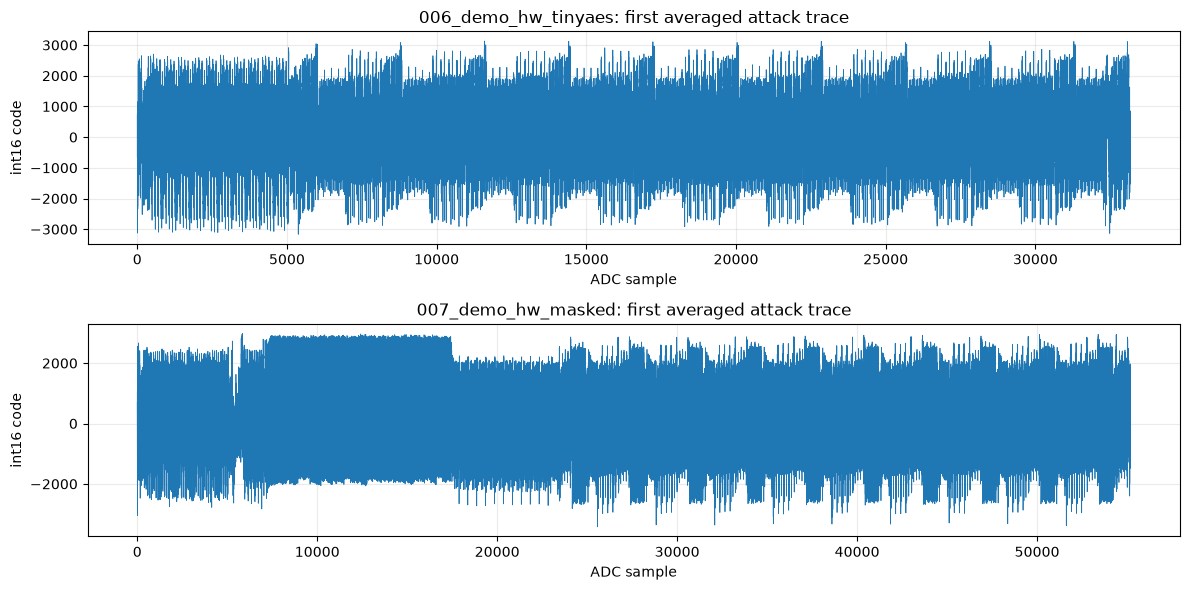

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6))
for ax, run_id in zip(axes, ('006_demo_hw_tinyaes', '007_demo_hw_masked')):
    with h5py.File(PROJECT / 'traces' / f'{run_id}.h5', 'r') as h5:
        trace = h5['attack/trace'][0]
    ax.plot(trace, lw=.55)
    ax.set(title=f'{run_id}: first averaged attack trace', xlabel='ADC sample', ylabel='int16 code')
    ax.grid(alpha=.25)
plt.tight_layout(); plt.show()

## Grok 4.6 xhigh 구조화 감사

감사는 호스트 Grok CLI에서 독립 안전성 평가 검증자 페르소나를 부여해 `grok-4.6`, `xhigh`로 수행했다. 웹·메모리·서브에이전트·편집·계획을 끄고 읽기 도구를 `cat`으로 제한했다. 입력은 네 `results.json`·분석 보고서·증거 manifest와 결정적 통합 요약뿐이다. Grok은 개별 시험의 수치나 판정을 바꾸지 않고 등급, `inconclusive`, tiny-AES-c CPA 양성 대조, 150 MHz 명목 메타데이터와 `shunt_max_verified=false` 문장 정합성을 감사한다. 총평에는 비공개 토큰별 사고 기록 대신 제3자가 재검산할 수 있는 관찰→파일·필드 근거→평가와 한계를 구조화해 남긴다. 인증정보와 세션 ID는 저장하지 않는다.

In [6]:
audit_path = PROJECT / 'runs/grok_audit.json'
audit = json.loads(audit_path.read_text(encoding='utf-8'))
assert audit['execution'] == demo.GROK_EXECUTION
assert audit['ok'] and all(audit['consistency'].values()) and not audit['issues']
assert demo.validate_grok_audit(audit)
display(audit)

{'ok': True,
 'consistency': {'grades': True,
  'inconclusive': True,
  'positive_control': True,
  'nominal_metadata': True},
 'issues': [],
 'assessor_review': {'persona': '독립된 안전성 평가 검증자',
  'overall_verdict': '지정 문서만으로 대조한 결과, 등급·inconclusive 표현·tiny-AES-c CPA 양성 대조·150 MHz 명목값·shunt_max_verified=false 문장은 서로 모순되지 않는다. A-Z 실행 무결성 통과는 암호 구현의 안전성 입증이 아니다.',
  'reasoning': [{'finding': '네 실험의 필수 시험 등급이 summary 비교표, 각 results.json tests.*.verdict, 각 02_analysis_report.md 판정 문장에서 동일하다.',
    'evidence': ['demo_0_1_summary.json comparison_rows[004]: ta=pass, spa=inconclusive, dpa=inconclusive, soundness=fail',
     '004_demo_emul_tinyaes/results.json tests.ta.verdict=pass, tests.spa.verdict=inconclusive, tests.dpa.verdict=inconclusive, tests.soundness.verdict=fail; 02_analysis_report.md 종합=fail, TA=pass, SPA=inconclusive, DPA=inconclusive, soundness=fail',
     'demo_0_1_summary.json comparison_rows[005]: ta=pass, spa=inconclusive, dpa=inconclusive, soundness=fail, soundness_candidates=2

## 최종 완료 조건

완료는 네 evidence bundle의 `verify`, 결정적 교차 검증 전 항목, Grok 구조화 감사가 모두 성공할 때만 표시한다. 복구 이력은 자연 발생한 단계만 HDF5에 남으며, 발생하지 않은 SAM reflash를 검수했다고 주장하지 않는다.

In [7]:
verify_results = {run_id: verify.verify(run_id) for run_id in demo.RUNS}
assert all(item['ok'] for item in verify_results.values())
assert summary['pre_grok_ok'] and all(summary['requirements'].values())
assert audit['ok']
print('✅ 분석·증거 검증·Grok 감사 완료 — 통합 마크다운 보고서 생성 준비')

✅ 분석·증거 검증·Grok 감사 완료 — 통합 마크다운 보고서 생성 준비


## 사용자를 위한 단일 마크다운 보고서 생성

마지막 단계는 노트북 화면에 흩어진 표·파형·판정을 결정적 통합 요약과 Grok 감사 JSON에서 다시 읽어 `demo/0.1.Demo_without_TraceWhisperer_Report.md` 한 파일로 렌더링한다. 보고서는 시험 판정을 재계산하거나 바꾸지 않으며, 한눈에 보는 결과표, 수집 무결성, 에뮬레이션·실측 대조, 명목 메타데이터, 복구 이력, 평가 한계를 포함한다. 마지막 총평에는 Grok 평가관의 관찰→원본 파일·필드 근거→평가 기록을 수록한다. 장비 전체 시리얼·인증정보는 입력하거나 기록하지 않는다.

In [8]:
report_path = demo.write_markdown_report(summary_path, audit_path)
markdown_reports = sorted((PROJECT / 'demo').glob('*.md'))
assert markdown_reports == [report_path], markdown_reports
report_text = report_path.read_text(encoding='utf-8')
for heading in ('## 한눈에 보는 결과', '## 완료 조건과 데이터 무결성',
                '## Grok 독립 평가관 총평', '### 최종 평가관 의견'):
    assert heading in report_text
assert audit['assessor_review']['final_commentary'] in report_text
print('✅ 0.1 Physical-AI-SCA 통합 데모 및 사용자 보고서 완료')
print('보고서:', report_path)
print('크기:', len(report_text.encode('utf-8')), 'bytes')

✅ 0.1 Physical-AI-SCA 통합 데모 및 사용자 보고서 완료
보고서: /workspace/[extra] Physical-AI-SCA/demo/0.1.Demo_without_TraceWhisperer_Report.md
크기: 13780 bytes
